In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('images/road.jpg')
if img is None:
    print("❌ 没读到图!检查:图叫 road.jpg 吗?在 images/ 里吗?")
else:
    print("✅ 读到了,shape:", img.shape)

gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray,(5,5),0)
edges = cv2.Canny(blur,50,150)
print("edges shape:",edges.shape)


✅ 读到了,shape: (204, 306, 3)
edges shape: (204, 306)


In [11]:
h,w = edges.shape
mask = np.zeros_like(edges)

vertices = np.array([[
    (0, int(0.7 * h)),
    (int(0.45 * w), int(0.5 * h)),
    (int(0.65 * w), int(0.5 * h)),
    (w, int(0.7 * h))
]],dtype=np.int32)

cv2.fillPoly(mask,vertices,255)
masked_edges = cv2.bitwise_and(edges, mask)

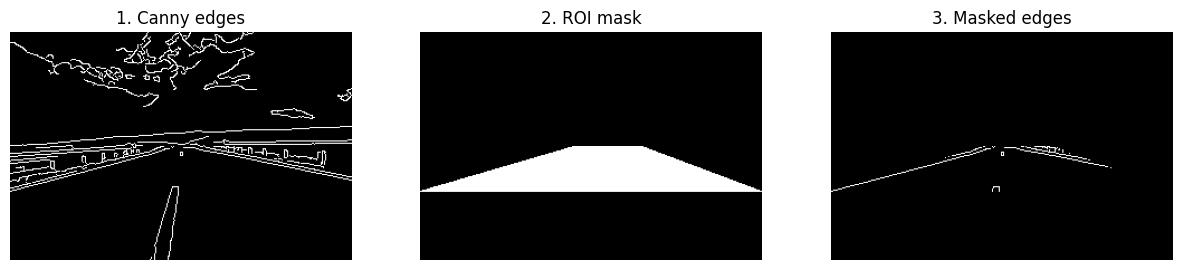

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(edges, cmap='gray');        axes[0].set_title('1. Canny edges')
axes[1].imshow(mask, cmap='gray');         axes[1].set_title('2. ROI mask')
axes[2].imshow(masked_edges, cmap='gray'); axes[2].set_title('3. Masked edges')
for ax in axes:
    ax.axis('off')
plt.show()